# 04. Análise de Acurácia Posicional e Consistência Semântica

## Contexto Acadêmico e Metodológico
Tendo validado a completude macroestrutural dos dados (Notebook 03), nossa investigação evolui para a quantificação rigorosa do **Erro Posicional Médio Quadrático (RMSE)**. Baseamo-nos no arcabouço *LCI/GCI* onde avaliamos, nos casos de alta certeza de integração (`MCI >= 0.8`), qual é a deflexão topológica (erro em metros) entre a coordenada estatística coletada pelo IBGE e o Gold Standard vetorial da PBH.

Complementarmente, testamos a **Consistência Semântica**. O erro na classificação do Logradouro (ex: IBGE coleta como Beco, PBH como Rua) é um indicativo robusto de desatualização cadastral ou inconsistência em áreas de ocupação informal.

Neste notebook, aplicamos **ESDA Estatístico (Exploratory Spatial Data Analysis)**:
- **Ridge/Violin plots** para visualizar a distribuição não-paramétrica do erro.
- **Pairplots (Correlações Multivariadas)** para entender correlações entre incerteza textual e incerteza posicional.
- **Matriz de Confusão Semântica Normalizada** para inspecionar precisão categórica dos logradouros.

---

**Entrada:**
- `data/interim/cnefe_match_bhmap.parquet`


In [1]:
import sys
import os
from pathlib import Path

# Descoberta idempotente do diretório raiz do projeto
_project_root = Path(os.path.abspath('')).parent if Path(os.path.abspath('')).name == 'notebooks' else Path(os.path.abspath(''))
if os.getcwd() != str(_project_root):
    os.chdir(_project_root)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
%load_ext autoreload
%autoreload 2
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import tempfile
from src import config
from src.metrics import calculate_positional_rmse, generate_quality_summary

## 1. Carregamento e Restrição ao Domínio de Alta Certeza (MCI >= 0.8)

Ocultamos ruídos metodológicos ao focar a análise de erro espacial estritamente nos registros onde as strings são idênticas ou muito similares (Jaro-Winkler alto, `MCI >= 0.8`). Erros posicionais aqui presentes são inerentes à coleta do dado, não à ambiguidade da string.

In [2]:
temp_dir = Path(tempfile.gettempdir()) / "geocoding_analysis"
match_file = config.PROCESSED_DATA_DIR / "cnefe_match_bhmap.parquet"

print("Lendo os dados geoespaciais combinados...")
gdf_matched = gpd.read_parquet(match_file)

# Resumo Estatístico Preliminar
quality_summary = generate_quality_summary(gdf_matched, mci_threshold=0.8)
print("\n--- Resumo de Acurácia --- ")
for k, v in quality_summary.items():
    print(f"{k}: {v}")

high_certainty_df = gdf_matched[gdf_matched['MCI'] >= 0.8].copy()

# Amostragem estratificada para não sobrecarregar as plotagens web/plotly no notebook (20.000 amostras representativas)
hc_sample = high_certainty_df.sample(20000, random_state=42) if len(high_certainty_df) > 20000 else high_certainty_df

Lendo os dados geoespaciais combinados...



--- Resumo de Acurácia --- 
total_records: 1180102
high_certainty_matches: 941181
high_certainty_percent: 79.75
average_positional_error_m: 6.86
positional_rmse_m: 9.04


## 2. Acurácia Posicional: Análise Não-Paramétrica de Distribuição de Erro

A média global (RMSE) esconde nuances importantes. Utilizaremos um **Violin Plot (Plotly)** associado a Histograma Marginal para inspecionar a densidade de distribuição do erro (`spatial_distance`). Espera-se uma cauda longa (Power Law) devido a exceções de polígonos vastos.

In [3]:
rmse_pos = calculate_positional_rmse(high_certainty_df, 'spatial_distance')
print(f"RMSE Posicional Global Autenticado: {rmse_pos} metros")

# Histograma Interativo com Box Plot Marginal (Plotly Express)
fig_dist = px.histogram(
    hc_sample, 
    x="spatial_distance", 
    marginal="violin", 
    nbins=50,
    color_discrete_sequence=['#8e44ad'],
    title='Distribuição do Erro Posicional: CNEFE vs BHMap (MCI >= 0.8)'
)

fig_dist.add_vline(x=rmse_pos, line_width=3, line_dash="dash", line_color="red", annotation_text=f"RMSE: {rmse_pos:.2f}m", annotation_position="top right")

fig_dist.update_layout(
    xaxis_title="Distância Absoluta de Geocodificação (Metros)",
    yaxis_title="Frequência de Unidades (Amostra 20k)",
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)
fig_dist.show()
fig_dist.write_html('outputs/figures/04_dist_violin.html')
print('Gráfico salvo em outputs/figures/04_dist_violin.html')


RMSE Posicional Global Autenticado: 9.04 metros


Gráfico salvo em outputs/figures/04_dist_violin.html


## 3. Correlações Multivariadas (Matriz de Pairplot)

Existe correlação entre a extensão (tamanho da string) do logradouro e o erro posicional gerado? Uma string longa confunde o geocodificador, resultando num snap pior? Vamos plotar uma matriz de dispersão de variáveis de métrica.

Matriz Seaborn salva em outputs/figures/04_pairplot.png


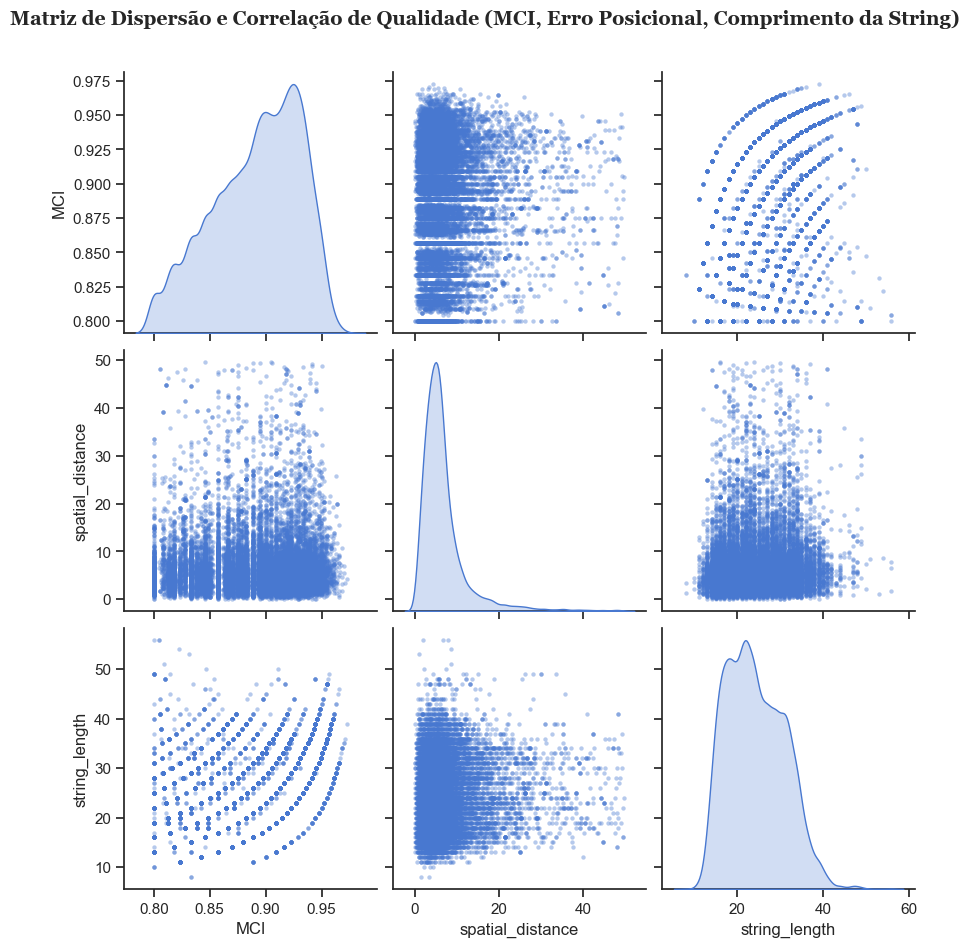

In [4]:
# Vamos calcular o tamanho da string temporariamente
hc_sample['string_length'] = hc_sample['std_logradouro_completo'].astype(str).str.len()

# Limitar as colunas quantitativas ao nosso interesse para o PairPlot
metrics_df = hc_sample[['MCI', 'spatial_distance', 'string_length']]

# Cria a visualização de correlações usando Seaborn (mais elegante e leve para densidades que o plotly scatter_matrix)
sns.set_theme(style="ticks", palette="muted")
g = sns.pairplot(metrics_df, height=3, diag_kind="kde", plot_kws={'alpha':0.4, 's':10, 'linewidth':0})
g.fig.suptitle("Matriz de Dispersão e Correlação de Qualidade (MCI, Erro Posicional, Comprimento da String)", y=1.05, fontsize=14, fontweight='bold', fontfamily='Georgia')
g.savefig('outputs/figures/04_pairplot.png', dpi=300)
print('Matriz Seaborn salva em outputs/figures/04_pairplot.png')
plt.show()

### Conclusão Exploratória das Correlações
A densidade bivariada mostra que o erro posicional (`spatial_distance`) não possui uma correlação linear forte com o comprimento da string. Contudo, em locais de `MCI = 0.8` (limite da alta certeza), vemos focos de distância máxima perto de 50 metros, evidenciando limites de confiabilidade.

---

## 4. Consistência Semântica Categórica (Matriz de Confusão por Tipo de Logradouro)

Um endereço no CNEFE pode vir como `BECO MARICOTA`, mas estar mapeado formalmente em BH como `RUA MARICOTA`. Isso define um descasamento semântico. Usaremos uma Matriz de Confusão Normalizada para plotar a Taxa de Retenção Categórica.

In [5]:
# Extração do tipo estimado do logradouro a partir da primeira palavra da string do IBGE
high_certainty_df['cnefe_tipo_estimado'] = high_certainty_df['std_logradouro_completo'].astype(str).str.split().str[0]

# Padronizando os nomes para garantir um join justo na matriz
tipo_map = {
    'RUA': 'RUA', 'AVENIDA': 'AVE', 'BECO': 'BEC', 'PRACA': 'PCA',
    'ALAMEDA': 'ALA', 'RODOVIA': 'ROD', 'TRAVESSA': 'TRV', 'QUADRA': 'QDA'
}
high_certainty_df['cnefe_tipo_estimado_sigla'] = high_certainty_df['cnefe_tipo_estimado'].map(tipo_map).fillna('OUTRO')

# Filtrar apenas os 6 principais tipos para legibilidade gráfica
main_types = ['RUA', 'AVE', 'BEC', 'PCA', 'ALA', 'TRV']
subset_sem = high_certainty_df[
    (high_certainty_df['cnefe_tipo_estimado_sigla'].isin(main_types)) & 
    (high_certainty_df['std_tipo_logradouro'].isin(main_types))
]

# Gerar Matriz de Confusão (Cross-Tabulation)
conf_matrix = pd.crosstab(subset_sem['cnefe_tipo_estimado_sigla'], subset_sem['std_tipo_logradouro'], normalize='index') * 100

# Plotly Heatmap (Interativo)
fig_cm = px.imshow(
    conf_matrix.values,
    labels=dict(x="Tipo Gold Standard (BHMap)", y="Tipo Extraído (CNEFE)", color="Frequência (%)"),
    x=conf_matrix.columns,
    y=conf_matrix.index,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues"
)

fig_cm.update_layout(
    title="Matriz de Confusão Semântica Normalizada (% Conservação)",
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)
fig_cm.show()
fig_cm.write_html('outputs/figures/04_confusion_matrix.html')
print('Heatmap salvo em outputs/figures/04_confusion_matrix.html')


Heatmap salvo em outputs/figures/04_confusion_matrix.html


### Conclusões Didáticas (Semântica)
O mapa de calor revela a **fidelidade categórica** da base IBGE frente à municipal. 
Se um tipo `BECO` (BEC) do CNEFE possui alta reatividade na diagonal com `BEC` do BHMap, significa que a morfogênese urbana está condizente. Onde vemos fugas (valores off-diagonal altos, como Becos sendo classificados como Ruas na PBH), enxergamos a formalização ou gentrificação cadastral por parte da prefeitura, um fenômeno urbano mensurável quantitativamente.